<a href="https://colab.research.google.com/github/Deepiga913/Neural-Networks/blob/main/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
'''
def f(x):
  return 3*x**2 - 4*x +5
'''

In [ ]:
#f(3.0)

20.0

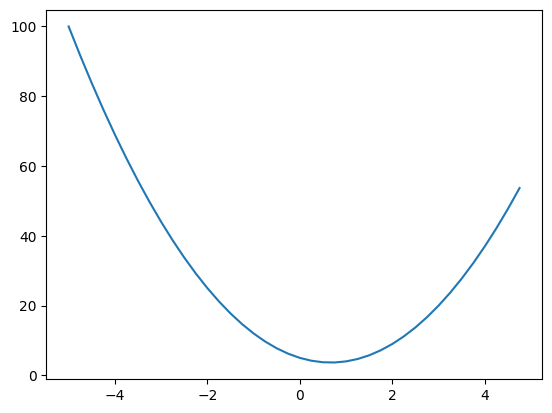

In [ ]:
'''
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
'''

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label= ''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')
    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def __rmul__(self, other): # other * self
    return self * other

  def __radd__(self, other): # other + self
    return self + other



'''
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L
'''

"  \na = Value(2.0, label = 'a')\nb = Value(-3.0, label = 'b')\nc = Value(10.0, label = 'c')\ne = a*b; e.label = 'e'\nd = e + c; d.label = 'd'\nf = Value(-2.0, label = 'f')\nL = d * f; L.label = 'L'\nL\n"

In [ ]:
a = Value(2.0)
b = Value(4.0)
b - a

Value( data = 2.0)

In [ ]:

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

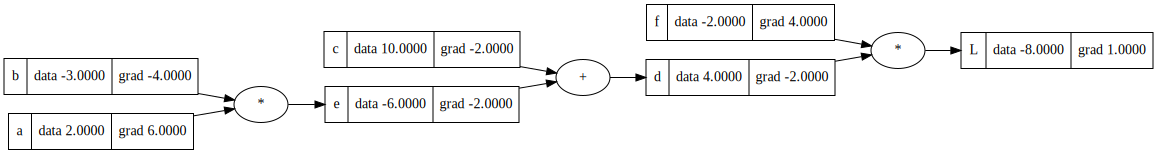

In [ ]:
draw_dot(L)

In [ ]:
#initializing gradients
'''
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
c.grad = 4.0
e.grad = -2.0
a.grad = (-3.0 * -2.0)
b.grad = (2.0 * -2.0)
'''


In [ ]:
'''
#nudging the leaf nodes by step function (i.e, 0.01)
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

#forward pass
e = a * b
d = e + c
L = d * f

print(L.data)
'''

-7.286496


In [ ]:
'''
def lol():
  h = 0.0001

  a = Value(2.0, label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label = 'f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0 , label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  d.data += h
  f = Value(-2.0, label = 'f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1) / h)

lol()
'''

-1.9999999999953388


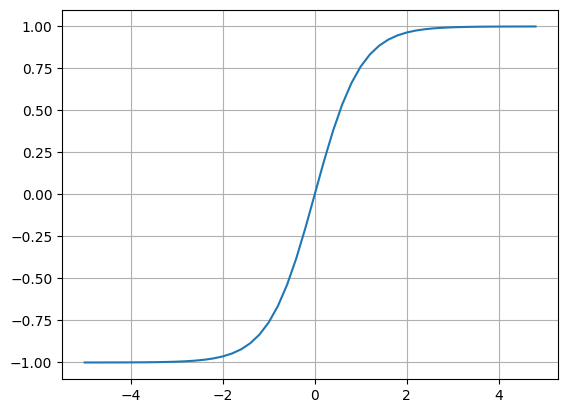

In [ ]:
#plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

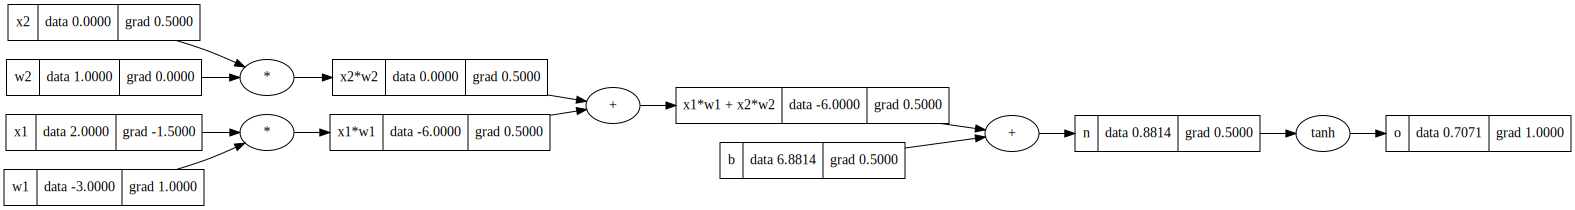

In [ ]:
draw_dot(o)

In [ ]:
#manual way
"""
o.grad = 1.0
n.grad = 1 - o.data**2
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
"""

In [ ]:
#functional way
"""
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()
"""

In [ ]:
#functional way using topological sort
'''
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()
'''

In [ ]:
#final functional call
o.backward()

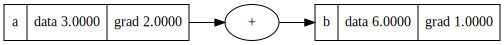

In [ ]:
#bug - eg1(fixed by accumulating the gradients instead of assigning them; see cell 5)
'''
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)
'''

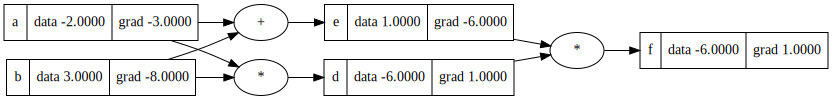

In [ ]:
#bug - eg2(fixed by accumulating the gradients instead of assigning them; see cell 5)
'''
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'
f.backward()
draw_dot(f)
'''

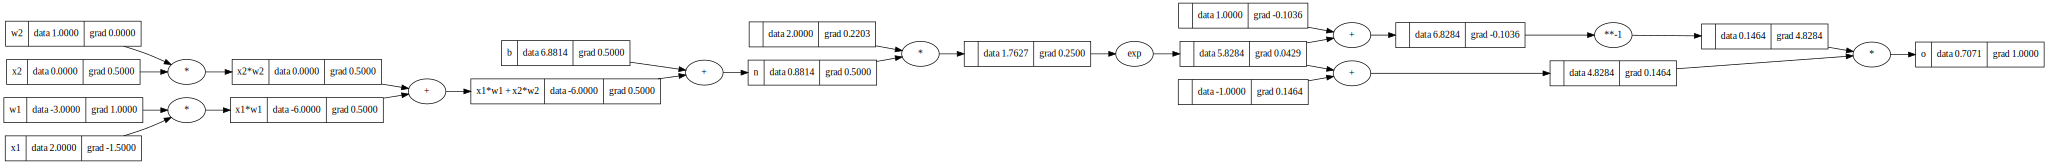

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#alternate to tanh; using tanh formula
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
import torch

In [ ]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

#print(o.data)
#print(o)
print(o.data.item())
o.backward()
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

tensor([0.7071], dtype=torch.float64)
tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
0.7071066904050358
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
import random

In [ ]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    #act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x): #x is input vector
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
x = [2.0, 3,0, -1.0]
# for a single neuron
#n = Neuron(2)
# for layers
#n = Layer(2, 3)
n = MLP(3, [4, 4, 1])
n(x)

Value(data = -0.04618497823260086)

In [ ]:
n.parameters()

[Value(data = -0.45560659729856834),
 Value(data = -0.9217923057963959),
 Value(data = -0.5425324237946265),
 Value(data = 0.08429158080081045),
 Value(data = -0.8971598207877736),
 Value(data = -0.5802284777058064),
 Value(data = 0.9197707565779369),
 Value(data = -0.19081174869528117),
 Value(data = 0.5524897369765536),
 Value(data = -0.7980734524841986),
 Value(data = 0.29328132071336),
 Value(data = -0.1854219649193165),
 Value(data = 0.13817215695538954),
 Value(data = -0.9437534809695283),
 Value(data = 0.14981903743830283),
 Value(data = 0.5100333594031268),
 Value(data = 0.2511349692252698),
 Value(data = 0.552015117730595),
 Value(data = -0.4555914313250995),
 Value(data = 0.8477292491750752),
 Value(data = 0.9523786290356906),
 Value(data = -0.3542326208838813),
 Value(data = -0.5004418473137744),
 Value(data = -0.7265569778141705),
 Value(data = -0.7989865608720035),
 Value(data = 0.6807724398838513),
 Value(data = 0.17988322159850179),
 Value(data = 0.6845770965687323),
 Va

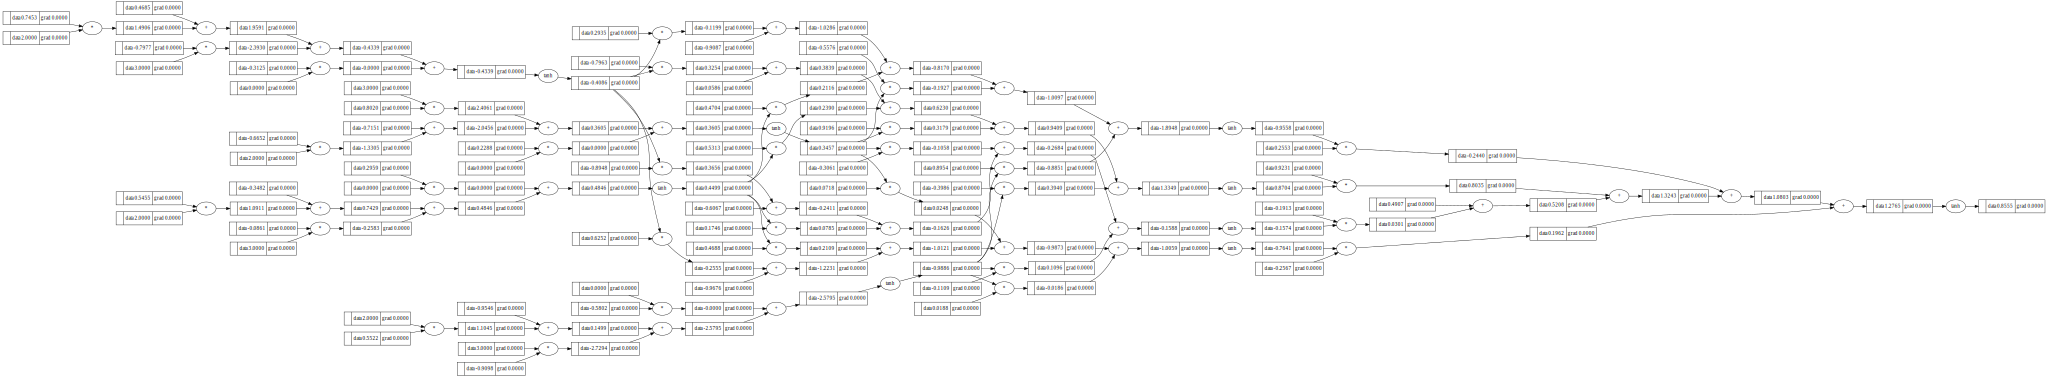

In [ ]:
draw_dot(n(x))

In [ ]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum([(yout - ygrt)**2 for ygrt, yout in zip(ys, ypred)])
  #backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  #update
  for p in n.parameters():
    p.data += -0.01 * p.grad

  print(k, loss.data)

0 0.01518737922134082
1 0.014451629226326767
2 0.013773758996178987
3 0.013147624783569074
4 0.012567891787191266
5 0.012029908288971837
6 0.011529602209763746
7 0.011063395612994312
8 0.010628133667419432
9 0.010221025327452634
10 0.009839593562689503
11 0.009481633410977195
12 0.00914517647363048
13 0.00882846074082522
14 0.008529904847310928
15 0.008248086026572458
16 0.007981721165317706
17 0.007729650467232284
18 0.007490823321068007
19 0.007264286037749163


In [ ]:
ypred

[Value(data = 0.9999451574480381),
 Value(data = -0.9364917876897525),
 Value(data = -0.943158228570262),
 Value(data = 0.9999450461138292)]

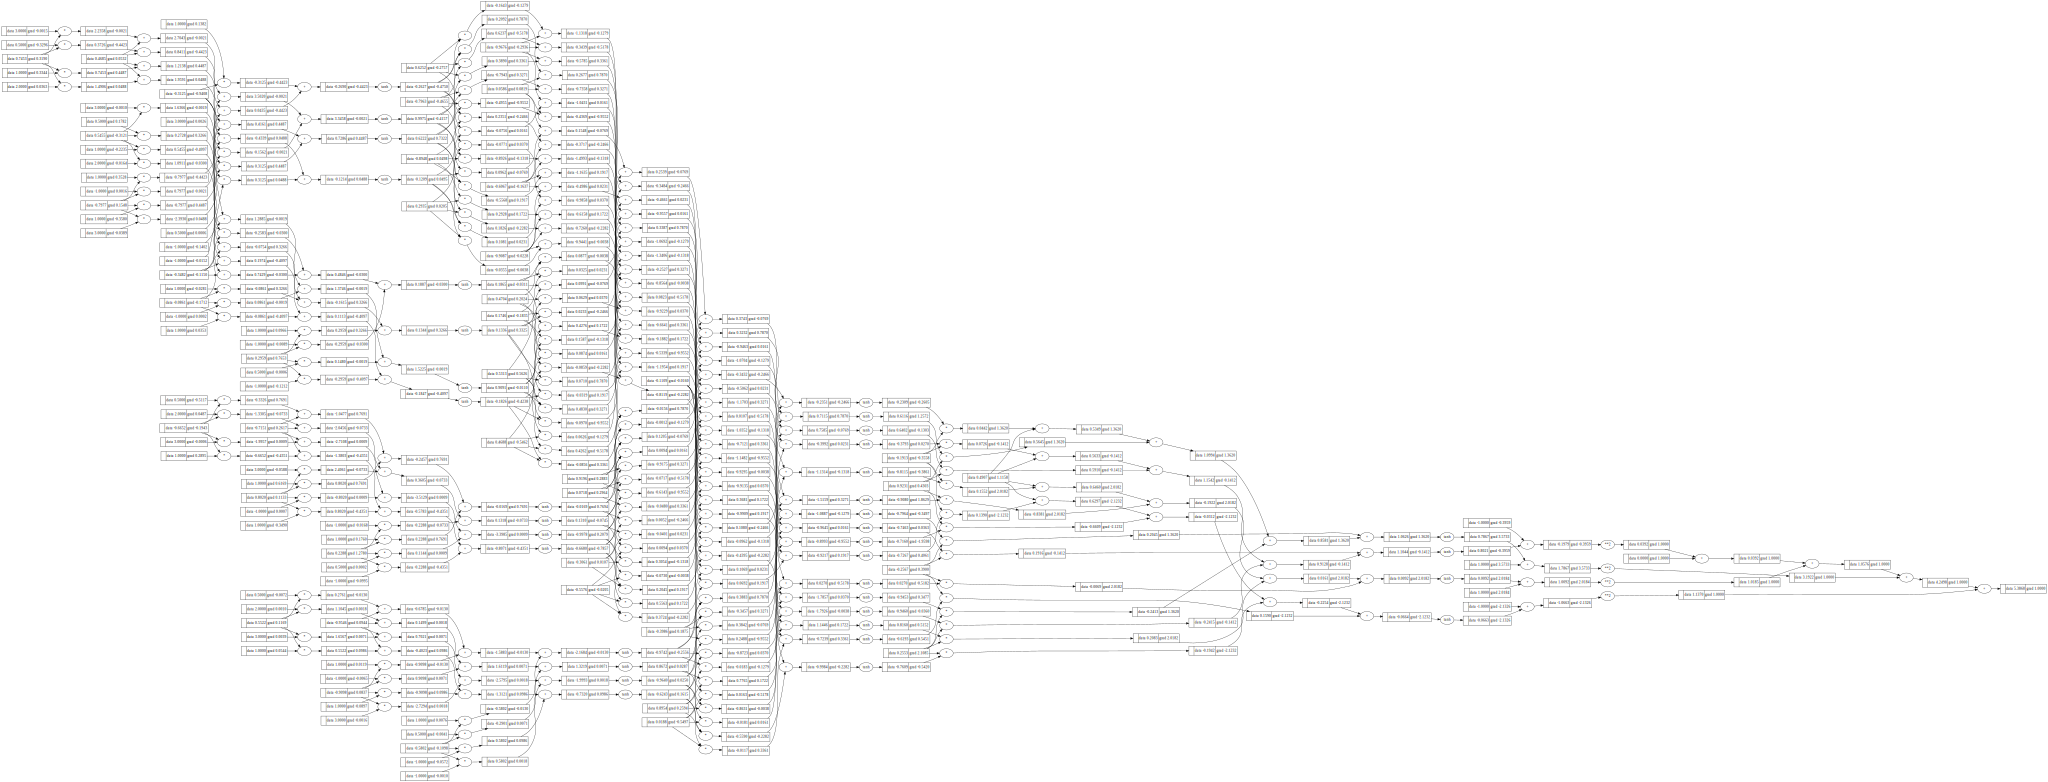

In [ ]:
draw_dot(loss)